#### Check

In [79]:
# Why: Confirm you are using the Courtesy only parsed JSON and that every row is labeled Courtesy.
import json, os

CLEAN_JSON = "/teamspace/studios/this_studio/data/ocr_ls_parsed_clean_courtesy.json"
assert os.path.exists(CLEAN_JSON), f"Missing: {CLEAN_JSON}"

items_c = json.load(open(CLEAN_JSON, "r"))
print("Courtesy JSON items:", len(items_c))

def is_courtesy_labels(labels):
    return any("courtesy" in str(x).lower() for x in (labels or []))

bad = [r for r in items_c if not is_courtesy_labels(r.get("region_labels", []))]
print("Not-courtesy rows inside Courtesy JSON:", len(bad))

print("First 3 labels examples:")
for r in items_c[:3]:
    print(r["cheque_id"], r.get("region_labels", []), "label:", repr(r.get("raw_label",""))[:30])


Courtesy JSON items: 1798
Not-courtesy rows inside Courtesy JSON: 0
First 3 labels examples:
ac00000 ['Courtesy'] label: '#48626#'
ac00001 ['Courtesy'] label: '#1350#'
ac00002 ['Courtesy'] label: '1500#'


In [80]:
# Why: Rebuild crops into a brand new folder so there is zero chance of mixing old Legal crops.
import os, json, shutil
import numpy as np
import cv2
from PIL import Image

IMG_ROOT = "/teamspace/studios/this_studio/data/CheckImages"
OUT_CROP_DIR = "/teamspace/studios/this_studio/data/courtesy_crops_ls_COURTESY_ONLY"
OUT_MANIFEST = "/teamspace/studios/this_studio/data/ocr_crops_manifest_COURTESY_ONLY.json"

# hard reset output folder to avoid mixed old/new
if os.path.exists(OUT_CROP_DIR):
    shutil.rmtree(OUT_CROP_DIR)
os.makedirs(OUT_CROP_DIR, exist_ok=True)

def read_tif_any(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is not None:
        return img
    with Image.open(path) as im:
        im = im.convert("RGB")
        arr = np.array(im, dtype=np.uint8)
        return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def clip_xyxy(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, int(round(x1))))
    y1 = max(0, min(H - 1, int(round(y1))))
    x2 = max(1, min(W,     int(round(x2))))
    y2 = max(1, min(H,     int(round(y2))))
    if x2 <= x1: x2 = min(W, x1 + 1)
    if y2 <= y1: y2 = min(H, y1 + 1)
    return x1, y1, x2, y2

# padding to protect strokes
PAD_X_FRAC = 0.08
PAD_Y_FRAC = 0.20

made, missing_tif = 0, 0
manifest = []

for it in items_c:
    cheque_id = it["cheque_id"]
    tif_path = os.path.join(IMG_ROOT, f"{cheque_id}.tif")
    if not os.path.exists(tif_path):
        missing_tif += 1
        continue

    bgr = read_tif_any(tif_path)
    H, W = bgr.shape[:2]

    x = (float(it["x_pct"]) / 100.0) * W
    y = (float(it["y_pct"]) / 100.0) * H
    w = (float(it["w_pct"]) / 100.0) * W
    h = (float(it["h_pct"]) / 100.0) * H

    x1, y1, x2, y2 = x, y, x + w, y + h
    pad_x = PAD_X_FRAC * (x2 - x1)
    pad_y = PAD_Y_FRAC * (y2 - y1)
    x1 -= pad_x; x2 += pad_x
    y1 -= pad_y; y2 += pad_y
    x1, y1, x2, y2 = clip_xyxy(x1, y1, x2, y2, W, H)

    patch = bgr[y1:y2, x1:x2]
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

    out_path = os.path.join(OUT_CROP_DIR, f"{cheque_id}.png")
    cv2.imwrite(out_path, gray)

    manifest.append({
        "cheque_id": cheque_id,
        "image_path": out_path,
        "digits_label": it["digits_label"],
        "raw_label": it["raw_label"],
        "region_labels": it.get("region_labels", []),
        "src_tif": tif_path,
        "bbox_px_padded_xyxy": [int(x1), int(y1), int(x2), int(y2)],
    })
    made += 1

json.dump(manifest, open(OUT_MANIFEST, "w"), indent=2, ensure_ascii=False)

print("Crops created:", made)
print("Missing tif:", missing_tif)
print("Crops dir:", OUT_CROP_DIR)
print("Manifest:", OUT_MANIFEST)


Crops created: 1775
Missing tif: 23
Crops dir: /teamspace/studios/this_studio/data/courtesy_crops_ls_COURTESY_ONLY
Manifest: /teamspace/studios/this_studio/data/ocr_crops_manifest_COURTESY_ONLY.json


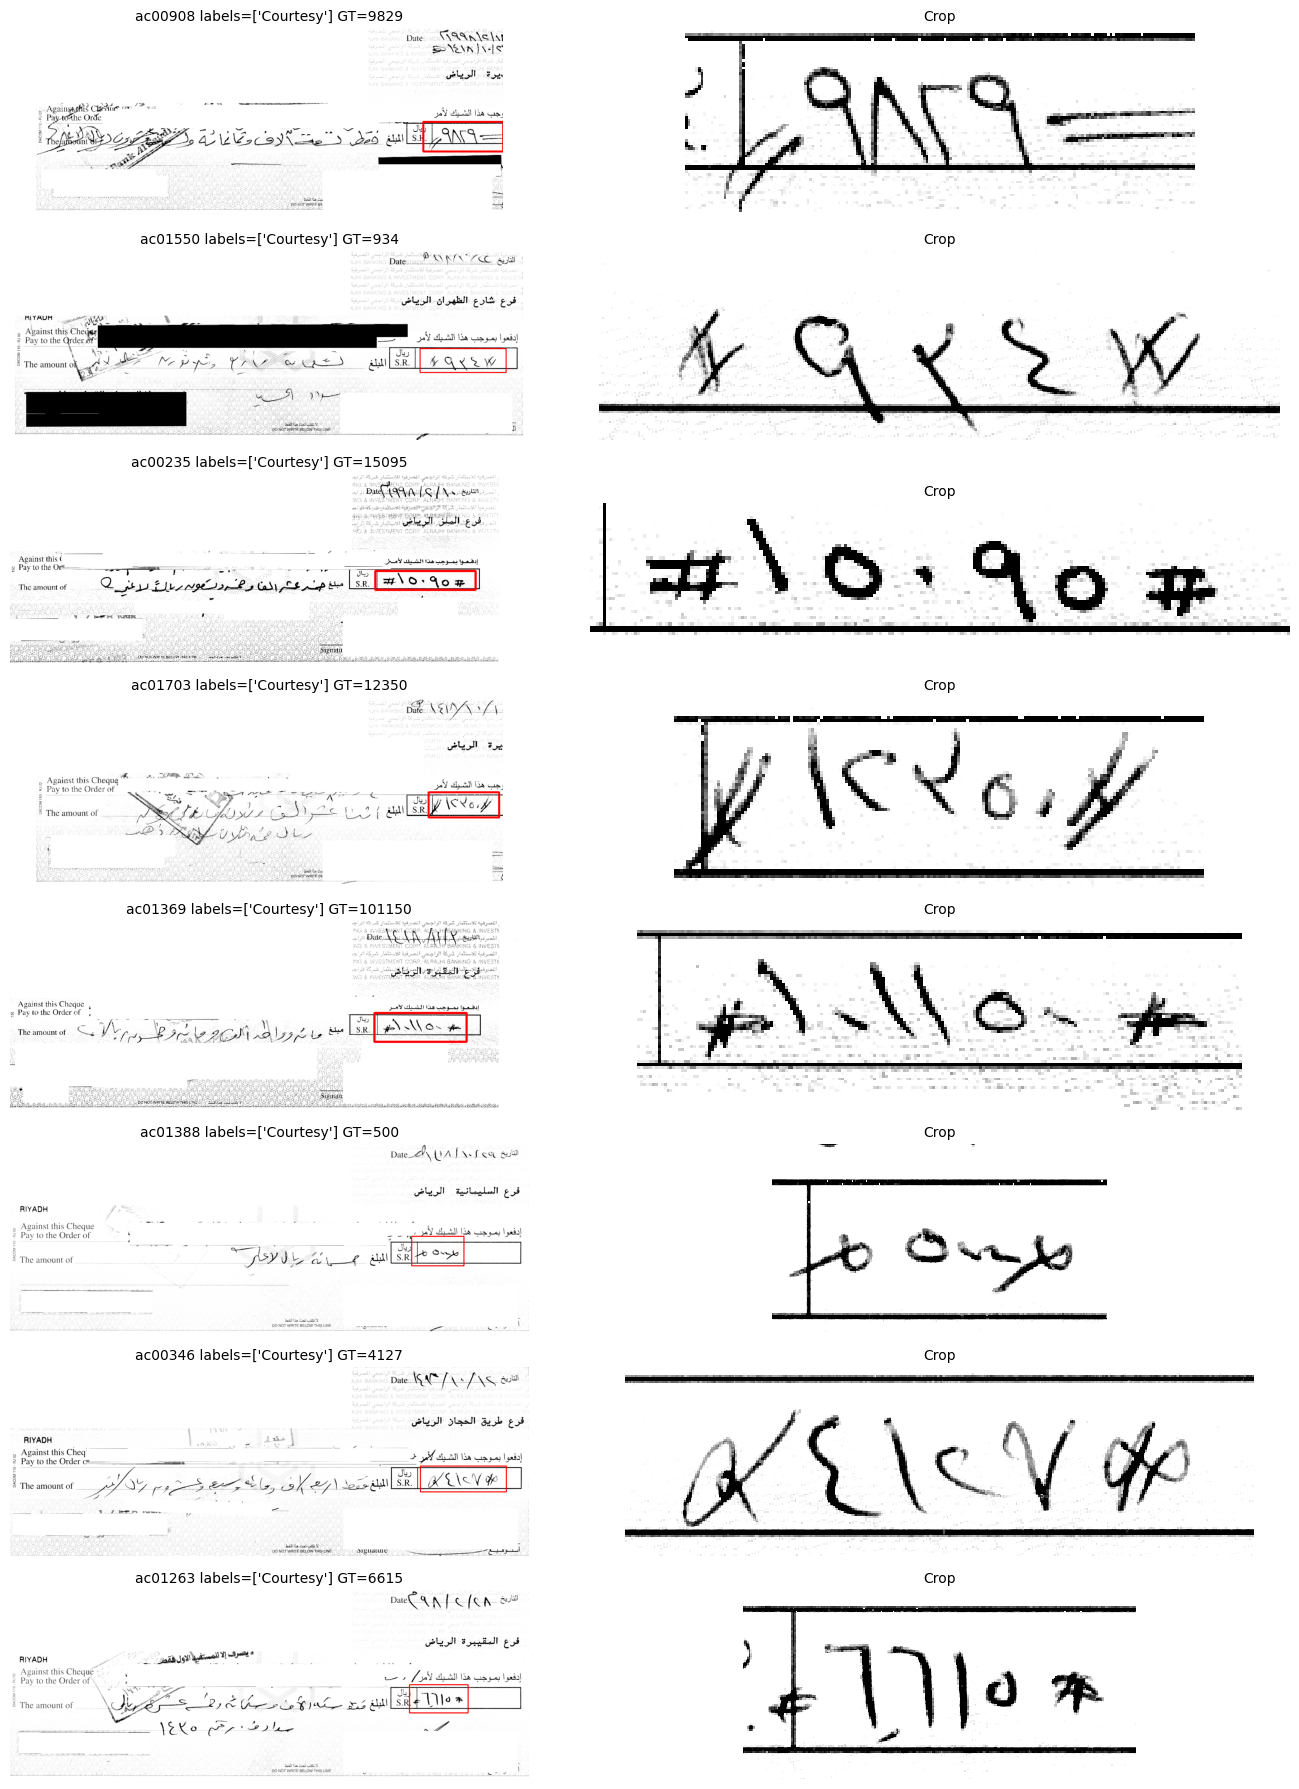

In [90]:
# Why: Visually confirm the crops are truly Courtesy by showing the bbox overlay and the cropped patch side by side.
import random
import matplotlib.pyplot as plt
import cv2

random.seed(222222222)
sample = manifest[:]
random.shuffle(sample)
sample = sample[:8]

plt.figure(figsize=(14, 18))
for i, r in enumerate(sample):
    bgr = read_tif_any(r["src_tif"]).copy()
    x1, y1, x2, y2 = r["bbox_px_padded_xyxy"]

    cv2.rectangle(bgr, (x1, y1), (x2, y2), (0, 0, 255), 4)
    overlay_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    crop = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)

    plt.subplot(8, 2, 2*i + 1)
    plt.imshow(overlay_rgb)
    plt.axis("off")
    plt.title(f"{r['cheque_id']} labels={r['region_labels']} GT={r['digits_label']}", fontsize=10)

    plt.subplot(8, 2, 2*i + 2)
    plt.imshow(crop, cmap="gray", interpolation="nearest")
    plt.axis("off")
    plt.title("Crop", fontsize=10)

plt.tight_layout()
plt.show()


#### Check

In [1]:
# Why: Define paths and imports once so every next cell uses the same settings.
import json, os, re
from collections import Counter

LS_JSON = "/teamspace/studios/this_studio/data/Json/project-1-at_JSON.json"
print("LS_JSON exists:", os.path.exists(LS_JSON), "|", LS_JSON)


LS_JSON exists: True | /teamspace/studios/this_studio/data/Json/project-1-at_JSON.json


In [46]:
# Why: Inspect a few tasks to prove the JSON has two regions and see which one is Courtesy vs Legal.
import json, os, re, random

LS_JSON = "/teamspace/studios/this_studio/data/Json/project-1-at_JSON.json"
data = json.load(open(LS_JSON, "r"))

def extract_image_ref(task: dict):
    d = task.get("data", {}) or {}
    if not d:
        return None
    return next(iter(d.values()))

def group_regions(task):
    anns = task.get("annotations", []) or []
    if not anns:
        return []
    res = anns[-1].get("result", []) or []

    regions = {}
    for r in res:
        t = r.get("type")
        v = r.get("value", {}) or {}
        if not all(k in v for k in ["x","y","width","height"]):
            continue
        key = (round(float(v["x"]),6), round(float(v["y"]),6), round(float(v["width"]),6), round(float(v["height"]),6), round(float(v.get("rotation",0.0) or 0.0),6))
        reg = regions.setdefault(key, {
            "x_pct": float(v["x"]), "y_pct": float(v["y"]),
            "w_pct": float(v["width"]), "h_pct": float(v["height"]),
            "rotation": float(v.get("rotation",0.0) or 0.0),
            "labels": [],
            "text": ""
        })

        if t in ["labels", "rectanglelabels"]:
            # Label Studio often uses "labels" or "rectanglelabels"
            labs = v.get("labels", None)
            if labs is None:
                labs = v.get("rectanglelabels", [])
            reg["labels"] = labs or []

        if t == "textarea":
            txt_list = v.get("text", [])
            txt = txt_list[0] if isinstance(txt_list, list) and len(txt_list) > 0 else ""
            reg["text"] = str(txt)

    return list(regions.values())

random.seed(0)
for t in random.sample(data, 5):
    img_ref = extract_image_ref(t)
    base = os.path.basename(str(img_ref))
    m = re.search(r"(ac\d+)", base)
    cheque_id = m.group(1) if m else "UNKNOWN"
    regs = group_regions(t)

    print("\nTask:", t.get("id"), "Cheque:", cheque_id, "Regions:", len(regs))
    for i, reg in enumerate(regs):
        print(" ", i, "labels:", reg["labels"], "| text:", repr(reg["text"])[:60], "| bbox%:", (round(reg["x_pct"],2), round(reg["y_pct"],2), round(reg["w_pct"],2), round(reg["h_pct"],2)))



Task: 1730 Cheque: ac01740 Regions: 2
  0 labels: ['Courtesy'] | text: '#15600#' | bbox%: (70.65, 50.47, 14.42, 9.66)
  1 labels: ['Legal'] | text: '' | bbox%: (19.08, 47.04, 40.89, 18.38)

Task: 789 Cheque: ac00795 Regions: 2
  0 labels: ['Courtesy'] | text: '1350//' | bbox%: (78.62, 50.64, 7.08, 10.21)
  1 labels: ['Legal'] | text: '' | bbox%: (24.46, 55.13, 44.92, 13.07)

Task: 1553 Cheque: ac01563 Regions: 2
  0 labels: ['Courtesy'] | text: '9855X' | bbox%: (79.15, 52.73, 9.61, 9.07)
  1 labels: ['Legal'] | text: '' | bbox%: (11.99, 48.7, 57.55, 16.79)

Task: 862 Cheque: ac00868 Regions: 2
  0 labels: ['Courtesy'] | text: '77900' | bbox%: (78.61, 49.58, 19.98, 9.86)
  1 labels: ['Legal'] | text: '' | bbox%: (16.4, 49.86, 53.2, 16.34)

Task: 83 Cheque: ac00082 Regions: 2
  0 labels: ['Courtesy'] | text: '#900#' | bbox%: (84.33, 54.58, 9.48, 8.54)
  1 labels: ['Legal'] | text: '' | bbox%: (43.51, 55.63, 24.14, 10.39)


In [47]:
# Why: Rebuild clean_items correctly by selecting the region whose label is Courtesy (not Legal).
import json, os, re
from collections import Counter

LS_JSON = "/teamspace/studios/this_studio/data/Json/project-1-at_JSON.json"
data = json.load(open(LS_JSON, "r"))

ARABIC_INDIC = str.maketrans("٠١٢٣٤٥٦٧٨٩", "0123456789")
EASTERN_ARABIC_INDIC = str.maketrans("۰۱۲۳۴۵۶۷۸۹", "0123456789")

def digits_only(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip()
    s = s.translate(ARABIC_INDIC).translate(EASTERN_ARABIC_INDIC)
    s = re.sub(r"[^0-9]", "", s)
    return s

def extract_image_ref(task: dict):
    d = task.get("data", {}) or {}
    if not d:
        return None
    return next(iter(d.values()))

def group_regions(task):
    anns = task.get("annotations", []) or []
    if not anns:
        return []
    res = anns[-1].get("result", []) or []

    regions = {}
    for r in res:
        t = r.get("type")
        v = r.get("value", {}) or {}
        if not all(k in v for k in ["x","y","width","height"]):
            continue
        key = (round(float(v["x"]),6), round(float(v["y"]),6), round(float(v["width"]),6), round(float(v["height"]),6), round(float(v.get("rotation",0.0) or 0.0),6))
        reg = regions.setdefault(key, {
            "x_pct": float(v["x"]), "y_pct": float(v["y"]),
            "w_pct": float(v["width"]), "h_pct": float(v["height"]),
            "rotation": float(v.get("rotation",0.0) or 0.0),
            "labels": [],
            "text": ""
        })

        if t in ["labels", "rectanglelabels"]:
            labs = v.get("labels", None)
            if labs is None:
                labs = v.get("rectanglelabels", [])
            reg["labels"] = labs or []

        if t == "textarea":
            txt_list = v.get("text", [])
            txt = txt_list[0] if isinstance(txt_list, list) and len(txt_list) > 0 else ""
            reg["text"] = str(txt)

    return list(regions.values())

def is_courtesy(labels):
    for lab in labels or []:
        if "courtesy" in str(lab).lower():
            return True
    return False

stats = Counter()
items = []

for t in data:
    img_ref = extract_image_ref(t)
    if not img_ref:
        stats["no_img_ref"] += 1
        continue
    base = os.path.basename(str(img_ref))
    m = re.search(r"(ac\d+)", base)
    if not m:
        stats["no_cheque_id"] += 1
        continue
    cheque_id = m.group(1)

    regs = group_regions(t)
    if len(regs) == 0:
        stats["no_regions"] += 1
        continue

    courtesy_regs = [r for r in regs if is_courtesy(r["labels"])]
    if len(courtesy_regs) == 0:
        stats["no_courtesy_region"] += 1
        continue

    # If there are multiple, take the first (usually only one)
    reg = courtesy_regs[0]
    raw = reg["text"]
    dig = digits_only(raw)

    if dig == "":
        stats["empty_digits"] += 1
        continue

    items.append({
        "task_id": t.get("id", None),
        "cheque_id": cheque_id,
        "x_pct": reg["x_pct"], "y_pct": reg["y_pct"],
        "w_pct": reg["w_pct"], "h_pct": reg["h_pct"],
        "rotation": reg["rotation"],
        "raw_label": raw,
        "digits_label": dig,
        "region_labels": reg["labels"],
    })
    stats["ok"] += 1

print("Rebuilt Courtesy items:", len(items))
print("Stats:", dict(stats))

OUT_CLEAN_JSON = "/teamspace/studios/this_studio/data/ocr_ls_parsed_clean_courtesy.json"
json.dump(items, open(OUT_CLEAN_JSON, "w"), indent=2, ensure_ascii=False)
print("Saved:", OUT_CLEAN_JSON)


Rebuilt Courtesy items: 1798
Stats: {'ok': 1798, 'no_courtesy_region': 1, 'empty_digits': 1}
Saved: /teamspace/studios/this_studio/data/ocr_ls_parsed_clean_courtesy.json


#### crop courtesy patches check

In [48]:
# Why: Use the corrected Courtesy-only JSON so crops are definitely from the Courtesy amount region.
CLEAN_JSON = "/teamspace/studios/this_studio/data/ocr_ls_parsed_clean_courtesy.json"
OUT_CROP_DIR = "/teamspace/studios/this_studio/data/courtesy_crops_ls_courtesy"
OUT_MANIFEST = "/teamspace/studios/this_studio/data/ocr_crops_manifest_courtesy.json"

IMG_ROOT = "/teamspace/studios/this_studio/data/CheckImages"

print("CLEAN_JSON exists:", os.path.exists(CLEAN_JSON))
print("IMG_ROOT exists:", os.path.exists(IMG_ROOT))

clean_items = json.load(open(CLEAN_JSON, "r"))
print("Clean items:", len(clean_items))

os.makedirs(OUT_CROP_DIR, exist_ok=True)


CLEAN_JSON exists: True
IMG_ROOT exists: True
Clean items: 1798


In [50]:
# Why: Define safe image reading, bbox conversion, padding, clipping, and enhancement in one place.
import numpy as np
import cv2
from PIL import Image

def read_tif_any(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is not None:
        return img
    with Image.open(path) as im:
        im = im.convert("RGB")
        arr = np.array(im, dtype=np.uint8)
        return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def clip_xyxy(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, int(round(x1))))
    y1 = max(0, min(H - 1, int(round(y1))))
    x2 = max(1, min(W,     int(round(x2))))
    y2 = max(1, min(H,     int(round(y2))))
    if x2 <= x1:
        x2 = min(W, x1 + 1)
    if y2 <= y1:
        y2 = min(H, y1 + 1)
    return x1, y1, x2, y2

def enhance_patch_to_gray(bgr: np.ndarray) -> np.ndarray:
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(g)
    return g

# Padding helps avoid cutting digit strokes when boxes are slightly tight.
PAD_X_FRAC = 0.08
PAD_Y_FRAC = 0.20

print("Padding set to:", "PAD_X_FRAC=", PAD_X_FRAC, "PAD_Y_FRAC=", PAD_Y_FRAC)


Padding set to: PAD_X_FRAC= 0.08 PAD_Y_FRAC= 0.2


In [51]:
# Why: Crop courtesy patches from the original .tif images using Label Studio bbox percentages, then save them for OCR training.
made = 0
missing_tif = 0
bad_bbox = 0
duplicate_cheque = 0

manifest = []
seen_cheque = set()

for it in clean_items:
    cheque_id = it["cheque_id"]

    # Protect against duplicates (should be rare)
    if cheque_id in seen_cheque:
        duplicate_cheque += 1
        continue
    seen_cheque.add(cheque_id)

    tif_path = os.path.join(IMG_ROOT, f"{cheque_id}.tif")
    if not os.path.exists(tif_path):
        missing_tif += 1
        continue

    bgr = read_tif_any(tif_path)
    H, W = bgr.shape[:2]

    # Convert percent bbox to pixel bbox
    x = (float(it["x_pct"]) / 100.0) * W
    y = (float(it["y_pct"]) / 100.0) * H
    w = (float(it["w_pct"]) / 100.0) * W
    h = (float(it["h_pct"]) / 100.0) * H

    if w <= 1 or h <= 1:
        bad_bbox += 1
        continue

    x1, y1, x2, y2 = x, y, x + w, y + h

    # Apply padding
    pad_x = PAD_X_FRAC * (x2 - x1)
    pad_y = PAD_Y_FRAC * (y2 - y1)
    x1 -= pad_x; x2 += pad_x
    y1 -= pad_y; y2 += pad_y

    x1, y1, x2, y2 = clip_xyxy(x1, y1, x2, y2, W, H)

    patch = bgr[y1:y2, x1:x2]
    patch_g = enhance_patch_to_gray(patch)

    out_path = os.path.join(OUT_CROP_DIR, f"{cheque_id}.png")
    ok = cv2.imwrite(out_path, patch_g)
    if not ok:
        continue

    manifest.append({
        "cheque_id": cheque_id,
        "image_path": out_path,
        "raw_label": it["raw_label"],
        "digits_label": it["digits_label"],
        "bbox_px_padded_xyxy": [int(x1), int(y1), int(x2), int(y2)],
        "src_tif": tif_path,
        "src_size_hw": [int(H), int(W)],
    })
    made += 1

json.dump(manifest, open(OUT_MANIFEST, "w"), indent=2, ensure_ascii=False)

print("Crops created:", made)
print("Missing .tif files:", missing_tif)
print("Bad bboxes skipped:", bad_bbox)
print("Duplicate cheque ids skipped:", duplicate_cheque)
print("Saved crops folder:", OUT_CROP_DIR)
print("Saved manifest:", OUT_MANIFEST)


Crops created: 1775
Missing .tif files: 17
Bad bboxes skipped: 0
Duplicate cheque ids skipped: 6
Saved crops folder: /teamspace/studios/this_studio/data/courtesy_crops_ls_courtesy
Saved manifest: /teamspace/studios/this_studio/data/ocr_crops_manifest_courtesy.json


In [52]:
# Why: Visually verify that cropping is correct by saving a few overlay images and the corresponding crops.
import cv2, os, random

DBG_DIR = "/teamspace/studios/this_studio/debug/b2_crop_check"
os.makedirs(DBG_DIR, exist_ok=True)

random.seed(0)
sample = manifest[:]
random.shuffle(sample)
sample = sample[:12]

for r in sample:
    bgr = read_tif_any(r["src_tif"]).copy()
    x1, y1, x2, y2 = r["bbox_px_padded_xyxy"]

    cv2.rectangle(bgr, (x1, y1), (x2, y2), (0, 0, 255), 4)
    cv2.putText(
        bgr,
        f"{r['cheque_id']} gt={r['digits_label']}",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 0, 255),
        2
    )

    out_overlay = os.path.join(DBG_DIR, f"{r['cheque_id']}_overlay.png")
    cv2.imwrite(out_overlay, bgr)

    # Copy crop for convenience
    crop = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)
    out_crop = os.path.join(DBG_DIR, f"{r['cheque_id']}_crop.png")
    cv2.imwrite(out_crop, crop)

print("Saved debug overlays and crops to:", DBG_DIR)


Saved debug overlays and crops to: /teamspace/studios/this_studio/debug/b2_crop_check


#### Preprocess

In [53]:
# Why: Create a "minimal and sharp" preprocessing that avoids downscaling and avoids blur by default.
import cv2
import numpy as np

def preprocess_ocr_patch_v2(gray: np.ndarray,
                            use_clahe: bool = True,
                            clahe_clip: float = 1.5,
                            clahe_grid=(8, 8),
                            denoise: str = "none",      # keep none by default
                            binarize: str = "none",     # keep none by default
                            target_h: int | None = None # None means keep original resolution
                           ) -> np.ndarray:
    if gray.dtype != np.uint8:
        gray = gray.astype(np.uint8)
    out = gray.copy()

    # Light contrast normalization (keep it gentle)
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=float(clahe_clip), tileGridSize=tuple(clahe_grid))
        out = clahe.apply(out)

    # Optional denoise (only enable if you truly see salt/pepper noise)
    if denoise == "median":
        out = cv2.medianBlur(out, 3)
    elif denoise == "bilateral":
        out = cv2.bilateralFilter(out, 3, 20, 20)
    elif denoise == "none":
        pass
    else:
        raise ValueError("denoise must be none|median|bilateral")

    # Optional light binarization (keep off unless it improves)
    if binarize == "otsu":
        _, out = cv2.threshold(out, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    elif binarize == "none":
        pass
    else:
        raise ValueError("binarize must be none|otsu")

    # Height normalize only if you want, and only upscale (never downscale)
    if target_h is not None:
        h, w = out.shape[:2]
        if target_h > h:
            scale = float(target_h) / float(h)
            new_w = max(1, int(round(w * scale)))
            out = cv2.resize(out, (new_w, target_h), interpolation=cv2.INTER_CUBIC)

    return out


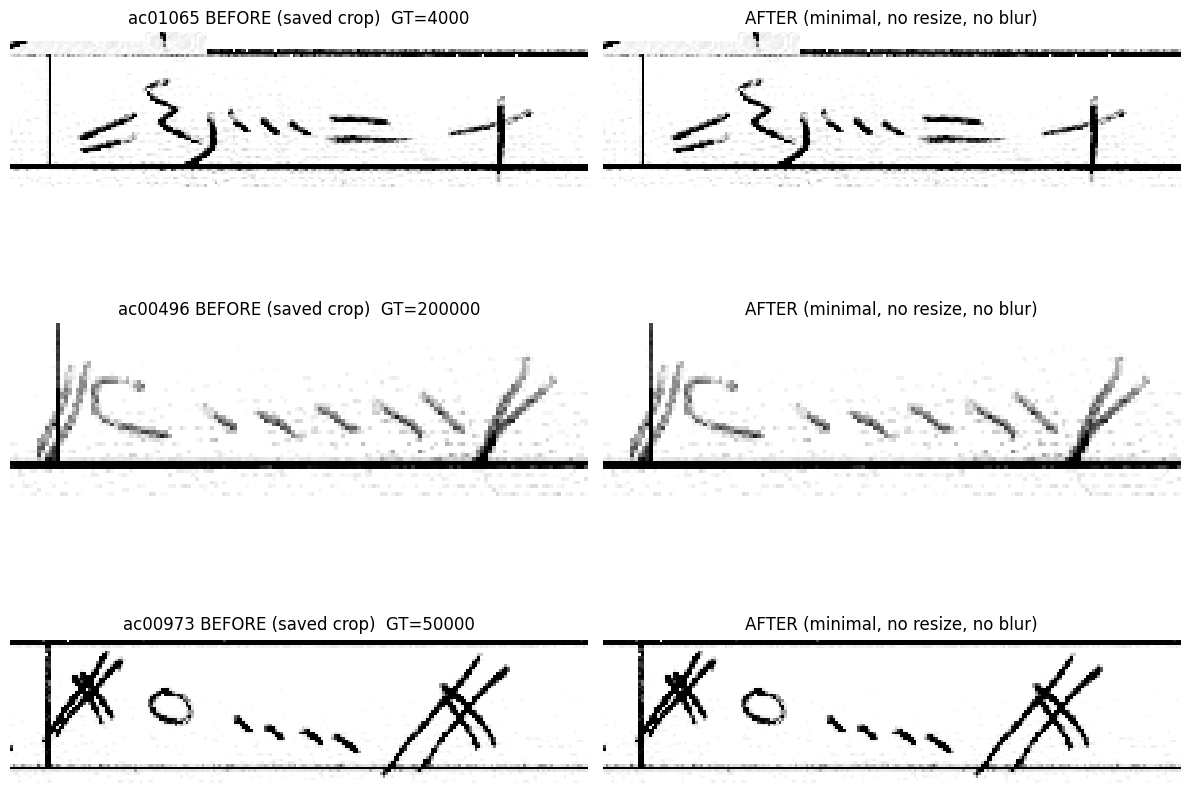

In [54]:
# Why: Show 3 samples side by side (before vs after) using nearest interpolation so the display does not look blurry.
import random
import matplotlib.pyplot as plt
import cv2
import os

random.seed(0)
samples = manifest[:]
random.shuffle(samples)
samples = samples[:3]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, r in enumerate(samples):
    # Use the already-saved crop (this is exactly what you'll train on)
    before = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)

    # Apply minimal preprocessing without downscaling or blur
    after = preprocess_ocr_patch_v2(
        before,
        use_clahe=False,      # IMPORTANT: you already CLAHE’d when saving crops
        denoise="none",
        binarize="none",
        target_h=None
    )

    axes[i, 0].imshow(before, cmap="gray", interpolation="nearest")
    axes[i, 0].set_title(f"{r['cheque_id']} BEFORE (saved crop)  GT={r['digits_label']}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(after, cmap="gray", interpolation="nearest")
    axes[i, 1].set_title("AFTER (minimal, no resize, no blur)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


#### Split train, val, test with stratification by digit length

In [91]:
# Why: Load the corrected Courtesy only manifest so splits and training use the right crops.
import json, os, random, csv
from collections import Counter, defaultdict

MANIFEST_PATH = "/teamspace/studios/this_studio/data/ocr_crops_manifest_COURTESY_ONLY.json"
assert os.path.exists(MANIFEST_PATH), f"Missing: {MANIFEST_PATH}"

manifest_c = json.load(open(MANIFEST_PATH, "r"))
print("Manifest samples:", len(manifest_c))

usable = []
for r in manifest_c:
    if os.path.exists(r["image_path"]) and r.get("digits_label","") != "":
        usable.append(r)

print("Usable samples:", len(usable))
print("Length counts top 10:", Counter(len(r["digits_label"]) for r in usable).most_common(10))


Manifest samples: 1775
Usable samples: 1775
Length counts top 10: [(4, 859), (5, 522), (6, 183), (3, 145), (7, 51), (8, 7), (9, 4), (2, 4)]


In [92]:
# Why: Create a stable stratified split so val and test have similar digit-length difficulty as train.
SEED = 42
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.80, 0.10, 0.10

def len_bin(n: int) -> int:
    if n <= 2: return 0
    if n <= 4: return 1
    if n <= 6: return 2
    if n <= 8: return 3
    return 4

random.seed(SEED)
tmp = usable[:]
random.shuffle(tmp)

bins = defaultdict(list)
for r in tmp:
    bins[len_bin(len(r["digits_label"]))].append(r)

train_c, val_c, test_c = [], [], []
for b in sorted(bins.keys()):
    g = bins[b]
    n = len(g)
    n_train = int(round(n * TRAIN_FRAC))
    n_val = int(round(n * VAL_FRAC))
    n_train = min(n_train, n)
    n_val = min(n_val, n - n_train)
    train_c += g[:n_train]
    val_c += g[n_train:n_train+n_val]
    test_c += g[n_train+n_val:]

print("Train:", len(train_c), "Val:", len(val_c), "Test:", len(test_c), "Total:", len(train_c)+len(val_c)+len(test_c))
print("Bin counts train:", Counter(len_bin(len(r['digits_label'])) for r in train_c))
print("Bin counts val  :", Counter(len_bin(len(r['digits_label'])) for r in val_c))
print("Bin counts test :", Counter(len_bin(len(r['digits_label'])) for r in test_c))


Train: 1419 Val: 176 Test: 180 Total: 1775
Bin counts train: Counter({1: 803, 2: 564, 3: 46, 0: 3, 4: 3})
Bin counts val  : Counter({1: 100, 2: 70, 3: 6})
Bin counts test : Counter({1: 101, 2: 71, 3: 6, 0: 1, 4: 1})


In [93]:
# Why: Save frozen splits so your training and reporting are reproducible.
OUT_SPLIT_DIR = "/teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY"
os.makedirs(OUT_SPLIT_DIR, exist_ok=True)

def write_csv(path, rows_):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["image_path", "digits_label", "raw_label", "cheque_id"])
        for r in rows_:
            w.writerow([r["image_path"], r["digits_label"], r.get("raw_label",""), r.get("cheque_id","")])

write_csv(os.path.join(OUT_SPLIT_DIR, "train.csv"), train_c)
write_csv(os.path.join(OUT_SPLIT_DIR, "val.csv"), val_c)
write_csv(os.path.join(OUT_SPLIT_DIR, "test.csv"), test_c)

print("Saved splits to:", OUT_SPLIT_DIR)


Saved splits to: /teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY


In [94]:
# Why: Replace train/val/test with the corrected Courtesy only split for the next training run.
train = train_c
val = val_c
test = test_c

print("Train/Val/Test:", len(train), len(val), len(test))


Train/Val/Test: 1419 176 180


In [95]:
# Why: Use a new output folder so this corrected run does not overwrite your previous run.
import os
RUN_NAME = "trocr_run_courtesy_only_v1"
OUT_DIR = f"/teamspace/studios/this_studio/output/{RUN_NAME}"
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)


OUT_DIR: /teamspace/studios/this_studio/output/trocr_run_courtesy_only_v1


#### Fine-tune TrOCR with cheque style augmentations + crop jitter

In [96]:
# Why: Remove any partially imported transformers modules and retry import cleanly.
import sys

for k in list(sys.modules.keys()):
    if k.startswith("transformers") or k.startswith("sklearn"):
        del sys.modules[k]

import transformers
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("transformers version:", transformers.__version__)
print("TrOCR imports OK now.")


transformers version: 4.57.3
TrOCR imports OK now.


In [97]:
# Why: Verify transformers and TrOCR classes import correctly after removing sklearn.
import transformers
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("transformers version:", transformers.__version__)
print("Imported TrOCRProcessor and VisionEncoderDecoderModel successfully.")


transformers version: 4.57.3
Imported TrOCRProcessor and VisionEncoderDecoderModel successfully.


In [98]:
# Why: Load a pretrained TrOCR model and processor so we can fine-tune instead of training from scratch.
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_NAME = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Basic generation settings (we will tune later if needed)
model.config.max_length = 32
model.config.num_beams = 2
model.config.early_stopping = True

print("Device:", device)
print("Model loaded:", MODEL_NAME)
print("Tokenizer pad id:", processor.tokenizer.pad_token_id)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Using a slow image processor

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of VisionEncode

Device: cuda
Model loaded: microsoft/trocr-base-handwritten
Tokenizer pad id: 1


In [99]:
# Why: Define OCR augmentations that mimic cheque variations and add crop jitter to prevent deletion errors from imperfect boxes.
import numpy as np
import cv2
from PIL import Image

def read_tif_any(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is not None:
        return img
    with Image.open(path) as im:
        im = im.convert("RGB")
        arr = np.array(im, dtype=np.uint8)
        return cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)

def clip_xyxy(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, int(round(x1))))
    y1 = max(0, min(H - 1, int(round(y1))))
    x2 = max(1, min(W,     int(round(x2))))
    y2 = max(1, min(H,     int(round(y2))))
    if x2 <= x1: x2 = min(W, x1 + 1)
    if y2 <= y1: y2 = min(H, y1 + 1)
    return x1, y1, x2, y2

def jitter_crop_from_tif(src_tif, bbox_xyxy, max_shift_x=0.03, max_shift_y=0.06, max_scale=0.03):
    bgr = read_tif_any(src_tif)
    H, W = bgr.shape[:2]
    x1, y1, x2, y2 = bbox_xyxy
    bw = max(2, x2 - x1)
    bh = max(2, y2 - y1)

    # random shift
    sx = int(round((np.random.uniform(-max_shift_x, max_shift_x)) * bw))
    sy = int(round((np.random.uniform(-max_shift_y, max_shift_y)) * bh))

    # random scale around center
    sc = 1.0 + float(np.random.uniform(-max_scale, max_scale))
    cx = (x1 + x2) / 2.0 + sx
    cy = (y1 + y2) / 2.0 + sy
    nw = bw * sc
    nh = bh * sc

    nx1 = cx - nw / 2.0
    ny1 = cy - nh / 2.0
    nx2 = cx + nw / 2.0
    ny2 = cy + nh / 2.0
    nx1, ny1, nx2, ny2 = clip_xyxy(nx1, ny1, nx2, ny2, W, H)

    patch = bgr[ny1:ny2, nx1:nx2]
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    return gray

def augment_gray(gray: np.ndarray,
                 p_rotate=0.7, max_deg=3.0,
                 p_blur=0.35,
                 p_noise=0.35,
                 p_morph=0.25):
    out = gray.copy()

    # small rotation
    if np.random.rand() < p_rotate:
        deg = float(np.random.uniform(-max_deg, max_deg))
        h, w = out.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
        out = cv2.warpAffine(out, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=255)

    # blur
    if np.random.rand() < p_blur:
        k = np.random.choice([3, 5])
        out = cv2.GaussianBlur(out, (k, k), 0)

    # noise
    if np.random.rand() < p_noise:
        sigma = float(np.random.uniform(3.0, 10.0))
        noise = np.random.normal(0, sigma, out.shape).astype(np.float32)
        out = np.clip(out.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    # slight erosion or dilation
    if np.random.rand() < p_morph:
        k = np.random.choice([1, 2])
        kernel = np.ones((k, k), np.uint8)
        if np.random.rand() < 0.5:
            out = cv2.erode(out, kernel, iterations=1)
        else:
            out = cv2.dilate(out, kernel, iterations=1)

    return out

def gray_to_pil_rgb(gray: np.ndarray) -> Image.Image:
    rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb)


In [100]:
# Why: Build a PyTorch dataset that returns pixel_values and labels, using crop jitter plus augmentations during training.
import torch
from torch.utils.data import Dataset

class ChequeOCRDataset(Dataset):
    def __init__(self, rows, processor, training: bool):
        self.rows = rows
        self.processor = processor
        self.training = training

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]

        if self.training:
            # Primary robustness trick: jitter crop from original tif using stored bbox
            gray = jitter_crop_from_tif(
                r["src_tif"],
                r["bbox_px_padded_xyxy"],
                max_shift_x=0.03,
                max_shift_y=0.06,
                max_scale=0.03
            )
            gray = augment_gray(gray)
        else:
            # Validation uses the saved crop, no augmentation
            gray = cv2.imread(r["image_path"], cv2.IMREAD_GRAYSCALE)

        pil = gray_to_pil_rgb(gray)

        enc = self.processor(images=pil, return_tensors="pt")
        pixel_values = enc["pixel_values"].squeeze(0)

        text = r["digits_label"]  # train on digits only for grading
        labels = self.processor.tokenizer(text, return_tensors="pt").input_ids.squeeze(0)

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


In [101]:
# Why: Use a collator that pads labels correctly and masks padding with -100 so loss is computed only on real tokens.
from dataclasses import dataclass
from typing import List, Dict, Any

@dataclass
class Collator:
    processor: TrOCRProcessor

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, Any]:
        pixel_values = torch.stack([b["pixel_values"] for b in batch])
        labels = [b["labels"] for b in batch]

        labels_padded = torch.nn.utils.rnn.pad_sequence(
            labels, batch_first=True, padding_value=self.processor.tokenizer.pad_token_id
        )

        labels_padded = labels_padded.clone()
        labels_padded[labels_padded == self.processor.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels_padded}

collator = Collator(processor)


In [102]:
# Why: Define an evaluation metric that matches your grading style by using edit distance on digits.
import re

def digits_only_text(s: str) -> str:
    return re.sub(r"[^0-9]", "", s or "")

def levenshtein(a: str, b: str) -> int:
    # standard DP
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, m + 1):
            cur = dp[j]
            cost = 0 if a[i - 1] == b[j - 1] else 1
            dp[j] = min(dp[j] + 1, dp[j - 1] + 1, prev + cost)
            prev = cur
    return dp[m]

def compute_metrics(eval_preds):
    pred_ids = eval_preds.predictions
    label_ids = eval_preds.label_ids

    if isinstance(pred_ids, tuple):
        pred_ids = pred_ids[0]

    pred_texts = processor.batch_decode(pred_ids, skip_special_tokens=True)

    # replace -100 with pad for decoding labels
    labels_for_decode = np.where(label_ids == -100, processor.tokenizer.pad_token_id, label_ids)
    label_texts = processor.batch_decode(labels_for_decode, skip_special_tokens=True)

    total_edits = 0
    total_len = 0
    exact = 0

    for p, g in zip(pred_texts, label_texts):
        p = digits_only_text(p)
        g = digits_only_text(g)
        if p == g:
            exact += 1
        total_edits += levenshtein(p, g)
        total_len += max(1, len(g))

    cer = total_edits / total_len
    exact_rate = exact / max(1, len(label_texts))
    return {"cer_digits": cer, "exact_match": exact_rate}


#### Training

In [103]:
# Why: Define training hyperparameters in one place so you know exactly what is being used.
HP = {
    "batch_size": 8,
    "epochs": 8,
    "lr": 5e-5,
    "warmup_steps": 200,
    "eval_every_steps": 250,
    "max_length": 32,
    "num_beams": 2,
    "use_fp16": True,
    "weight_decay": 0.01,
}
HP


{'batch_size': 8,
 'epochs': 8,
 'lr': 5e-05,
 'warmup_steps': 200,
 'eval_every_steps': 250,
 'max_length': 32,
 'num_beams': 2,
 'use_fp16': True,
 'weight_decay': 0.01}

In [104]:
# Why: Create DataLoaders for train and val so we can iterate batches without Trainer.
import torch
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=HP["batch_size"], shuffle=True, collate_fn=collator, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=HP["batch_size"], shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train batches: 178
Val batches  : 22


In [105]:
# Why: Use a version proof optimizer and scheduler so training works even if transformers changed its imports.
import math
import torch

from torch.optim import AdamW  # recommended now :contentReference[oaicite:1]{index=1}

# Scheduler import can vary by transformers version, so we import from optimization explicitly. :contentReference[oaicite:2]{index=2}
try:
    from transformers.optimization import get_linear_schedule_with_warmup
except Exception:
    get_linear_schedule_with_warmup = None

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

total_steps = len(train_loader) * HP["epochs"]
optimizer = AdamW(model.parameters(), lr=HP["lr"], weight_decay=HP["weight_decay"])

if get_linear_schedule_with_warmup is not None:
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=HP["warmup_steps"],
        num_training_steps=total_steps,
    )
else:
    # Fallback scheduler: warmup then linear decay (no transformers dependency)
    def lr_lambda(step):
        if step < HP["warmup_steps"]:
            return float(step) / float(max(1, HP["warmup_steps"]))
        return max(
            0.0,
            float(total_steps - step) / float(max(1, total_steps - HP["warmup_steps"]))
        )
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = (device == "cuda") and HP["use_fp16"]
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print("Device:", device)
print("Total training steps:", total_steps)
print("Warmup steps:", HP["warmup_steps"])
print("AMP enabled:", use_amp)
print("Scheduler:", type(scheduler).__name__)


Device: cuda
Total training steps: 1424
Warmup steps: 200
AMP enabled: True
Scheduler: LambdaLR


/tmp/ipykernel_3484/2280632839.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [106]:
# Why: Tell the VisionEncoderDecoderModel how to build decoder inputs from labels during training (fixes decoder_start_token_id error).
model.config.decoder_start_token_id = processor.tokenizer.eos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# (Optional but safe for generation)
model.config.eos_token_id = processor.tokenizer.eos_token_id

print("decoder_start_token_id:", model.config.decoder_start_token_id)
print("pad_token_id         :", model.config.pad_token_id)
print("eos_token_id         :", model.config.eos_token_id)
print("vocab_size           :", model.config.vocab_size)


decoder_start_token_id: 2
pad_token_id         : 1
eos_token_id         : 2
vocab_size           : 50265


In [107]:
# Why: Train the model and evaluate on val every N steps to confirm it is improving (lower digit edit distance, higher exact match).
import numpy as np
import os, time

OUT_DIR = "/teamspace/studios/this_studio/output_trocr_digits_manual"
os.makedirs(OUT_DIR, exist_ok=True)

model.config.max_length = HP["max_length"]
model.config.num_beams = HP["num_beams"]

def eval_on_val():
    model.eval()
    all_preds, all_gts = [], []

    with torch.no_grad():
        for batch in val_loader:
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device)

            gen_ids = model.generate(
                pixel_values=pixel_values,
                max_length=HP["max_length"],
                num_beams=HP["num_beams"],
            )
            pred_texts = processor.batch_decode(gen_ids, skip_special_tokens=True)

            labels_cpu = labels.detach().cpu().numpy()
            labels_cpu = np.where(labels_cpu == -100, processor.tokenizer.pad_token_id, labels_cpu)
            gt_texts = processor.batch_decode(labels_cpu, skip_special_tokens=True)

            all_preds.extend(pred_texts)
            all_gts.extend(gt_texts)

    # compute our digits metrics
    total_edits, total_len, exact = 0, 0, 0
    for p, g in zip(all_preds, all_gts):
        p = digits_only_text(p)
        g = digits_only_text(g)
        if p == g:
            exact += 1
        total_edits += levenshtein(p, g)
        total_len += max(1, len(g))

    cer = total_edits / total_len
    exact_rate = exact / max(1, len(all_gts))
    return {"cer_digits": cer, "exact_match": exact_rate}

best_cer = 1e9
global_step = 0

for epoch in range(1, HP["epochs"] + 1):
    model.train()
    t0 = time.time()

    for batch in train_loader:
        global_step += 1
        optimizer.zero_grad(set_to_none=True)

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        with torch.cuda.amp.autocast(enabled=use_amp):
            out = model(pixel_values=pixel_values, labels=labels)
            loss = out.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        if global_step % 50 == 0:
            print(f"epoch {epoch} step {global_step} loss {loss.item():.4f}")

        if global_step % HP["eval_every_steps"] == 0:
            metrics = eval_on_val()
            print(f"[VAL] step {global_step} cer_digits={metrics['cer_digits']:.4f} exact={metrics['exact_match']:.4f}")

            if metrics["cer_digits"] < best_cer:
                best_cer = metrics["cer_digits"]
                save_dir = os.path.join(OUT_DIR, "best")
                os.makedirs(save_dir, exist_ok=True)
                model.save_pretrained(save_dir)
                processor.save_pretrained(save_dir)
                print("Saved new best to:", save_dir)

    print(f"Epoch {epoch} finished in {(time.time()-t0)/60:.2f} min")

print("Training done. Best val cer_digits:", best_cer)


/tmp/ipykernel_3484/819415064.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1 step 50 loss 3.4686
epoch 1 step 100 loss 3.8158
epoch 1 step 150 loss 3.7333
Epoch 1 finished in 0.75 min
epoch 2 step 200 loss 3.5163
epoch 2 step 250 loss 3.2530


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/generation/utils.py:1733: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


[VAL] step 250 cer_digits=0.4275 exact=0.0966


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 32, 'early_stopping': True, 'num_beams': 2}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Saved new best to: /teamspace/studios/this_studio/output_trocr_digits_manual/best
epoch 2 step 300 loss 1.6705
epoch 2 step 350 loss 2.3875
Epoch 2 finished in 0.92 min
epoch 3 step 400 loss 1.9253
epoch 3 step 450 loss 1.9397
epoch 3 step 500 loss 1.5284
[VAL] step 500 cer_digits=0.5242 exact=0.1250
Epoch 3 finished in 0.87 min
epoch 4 step 550 loss 1.6556
epoch 4 step 600 loss 1.1188
epoch 4 step 650 loss 1.5137
epoch 4 step 700 loss 1.6625
Epoch 4 finished in 0.76 min
epoch 5 step 750 loss 1.7524
[VAL] step 750 cer_digits=0.5649 exact=0.1250
epoch 5 step 800 loss 2.5383
epoch 5 step 850 loss 0.5595
Epoch 5 finished in 0.86 min
epoch 6 step 900 loss 1.7455
epoch 6 step 950 loss 0.6817
epoch 6 step 1000 loss 0.7176
[VAL] step 1000 cer_digits=0.5369 exact=0.1080
epoch 6 step 1050 loss 0.6597
Epoch 6 finished in 0.88 min
epoch 7 step 1100 loss 0.4311
epoch 7 step 1150 loss 1.3356
epoch 7 step 1200 loss 1.0857
Epoch 7 finished in 0.76 min
epoch 8 step 1250 loss 0.4392
[VAL] step 1250 cer

In [109]:
# Why: Check if your notebook still has an OUT_DIR variable from training so we can use it directly.
import os

print("OUT_DIR in globals:", "OUT_DIR" in globals())
if "OUT_DIR" in globals():
    print("OUT_DIR =", OUT_DIR)
    print("OUT_DIR exists:", os.path.exists(OUT_DIR))
    print("OUT_DIR/best exists:", os.path.exists(os.path.join(OUT_DIR, "best")))


OUT_DIR in globals: True
OUT_DIR = /teamspace/studios/this_studio/output_trocr_digits_manual
OUT_DIR exists: True
OUT_DIR/best exists: True


In [110]:
# Why: List the most likely output folders where your best model could be saved.
import os

candidates = [
    "/teamspace/studios/this_studio/output",
    "/teamspace/studios/this_studio/output_trocr_digits_manual",
    "/teamspace/studios/this_studio/output_trocr_digits",
]

for p in candidates:
    print("\nPath:", p, "exists:", os.path.exists(p))
    if os.path.exists(p):
        print("  top entries:", sorted(os.listdir(p))[:30])



Path: /teamspace/studios/this_studio/output exists: True
  top entries: ['trocr_run_courtesy_only_v1']

Path: /teamspace/studios/this_studio/output_trocr_digits_manual exists: True
  top entries: ['best']

Path: /teamspace/studios/this_studio/output_trocr_digits exists: True
  top entries: []


In [111]:
# Why: Search for any folder named "best" that contains a TrOCR model (config + weights), then pick the newest one.
import os, time

def is_trocr_dir(d):
    if not os.path.isdir(d):
        return False
    files = set(os.listdir(d))
    has_config = "config.json" in files
    has_processor = ("preprocessor_config.json" in files) or ("tokenizer_config.json" in files)
    has_weights = ("pytorch_model.bin" in files) or ("model.safetensors" in files)
    return has_config and has_weights and has_processor

roots = [
    "/teamspace/studios/this_studio",
]

found = []
for root in roots:
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == "best" and is_trocr_dir(dirpath):
            found.append(dirpath)

print("Found best checkpoints:", len(found))
for d in found[:30]:
    print(" -", d)

if len(found) == 0:
    print("\nNo best folder found. That means your training loop might not have saved, or saved to a different name.")
else:
    found_sorted = sorted(found, key=lambda d: os.path.getmtime(d), reverse=True)
    BEST_DIR = found_sorted[0]
    print("\nNewest BEST_DIR:", BEST_DIR)
    print("Last modified:", time.ctime(os.path.getmtime(BEST_DIR)))


Found best checkpoints: 1
 - /teamspace/studios/this_studio/output_trocr_digits_manual/best

Newest BEST_DIR: /teamspace/studios/this_studio/output_trocr_digits_manual/best
Last modified: Wed Dec 17 22:47:55 2025


In [112]:
# Why: Load the best checkpoint we found so you can evaluate and visualize predictions.
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

assert "BEST_DIR" in globals(), "BEST_DIR not set. Run FIND.2 first."

processor = TrOCRProcessor.from_pretrained(BEST_DIR)
model = VisionEncoderDecoderModel.from_pretrained(BEST_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("Loaded BEST_DIR:", BEST_DIR)
print("Device:", device)
print("Files:", sorted(os.listdir(BEST_DIR))[:20])


Loaded BEST_DIR: /teamspace/studios/this_studio/output_trocr_digits_manual/best
Device: cuda
Files: ['config.json', 'generation_config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']


In [119]:
# Why: Get the exact Part B numbers (I, D, S, digit accuracy, 0/1/2+ error) so we know what to fix.
import os, csv, re, torch
import numpy as np
from PIL import Image

SPLIT_DIR = "/teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY"
VAL_CSV = os.path.join(SPLIT_DIR, "val.csv")
TEST_CSV = os.path.join(SPLIT_DIR, "test.csv")

def read_csv_rows(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        rdr = csv.DictReader(f)
        for r in rdr:
            rows.append(r)
    return rows

val_rows = read_csv_rows(VAL_CSV)
test_rows = read_csv_rows(TEST_CSV)

def digits_only_text(s: str) -> str:
    return re.sub(r"[^0-9]", "", s or "")

def edit_ops_counts(pred: str, gt: str):
    pred = pred or ""
    gt = gt or ""
    n, m = len(gt), len(pred)
    dp = [[0]*(m+1) for _ in range(n+1)]
    op = [[None]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        dp[i][0] = i; op[i][0] = "D"
    for j in range(1, m+1):
        dp[0][j] = j; op[0][j] = "I"
    for i in range(1, n+1):
        for j in range(1, m+1):
            if gt[i-1] == pred[j-1]:
                dp[i][j] = dp[i-1][j-1]; op[i][j] = "M"
            else:
                sub = dp[i-1][j-1] + 1
                ins = dp[i][j-1] + 1
                dele = dp[i-1][j] + 1
                best = min(sub, ins, dele)
                dp[i][j] = best
                op[i][j] = "S" if best == sub else ("I" if best == ins else "D")
    i, j = n, m
    I = D = S = 0
    while i > 0 or j > 0:
        cur = op[i][j]
        if cur == "M":
            i -= 1; j -= 1
        elif cur == "S":
            S += 1; i -= 1; j -= 1
        elif cur == "I":
            I += 1; j -= 1
        elif cur == "D":
            D += 1; i -= 1
        else:
            break
    return I, D, S, dp[n][m]

def batch_predict(paths, batch_size=8, max_length=32, num_beams=2):
    preds_raw = []
    for i in range(0, len(paths), batch_size):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i+batch_size]]
        enc = processor(images=imgs, return_tensors="pt", padding=True)
        pv = enc["pixel_values"].to(device)
        with torch.no_grad():
            ids = model.generate(pv, max_length=max_length, num_beams=num_beams)
        txt = processor.batch_decode(ids, skip_special_tokens=True)
        preds_raw.extend(txt)
    return preds_raw

def eval_split(rows, name):
    paths = [r["image_path"] for r in rows]
    gt = [digits_only_text(r["digits_label"]) for r in rows]
    pr_raw = batch_predict(paths, batch_size=8, max_length=32, num_beams=2)
    pr = [digits_only_text(x) for x in pr_raw]

    total_I = total_D = total_S = 0
    total_gt_digits = 0
    exact = 0
    buckets = {"0":0,"1":0,"2+":0}

    worst = []  # (dist, idx, gt, pred, raw)

    for idx, (p, g, raw) in enumerate(zip(pr, gt, pr_raw)):
        I, D, S, dist = edit_ops_counts(p, g)
        total_I += I; total_D += D; total_S += S
        total_gt_digits += max(1, len(g))
        if p == g: exact += 1
        if dist == 0: buckets["0"] += 1
        elif dist == 1: buckets["1"] += 1
        else: buckets["2+"] += 1
        worst.append((dist, idx, g, p, raw))

    digit_acc = 1.0 - (total_I + total_D + total_S) / float(total_gt_digits)

    print(f"\n=== {name} ===")
    print("Samples:", len(rows))
    print("I,D,S:", total_I, total_D, total_S)
    print("Digit accuracy:", round(digit_acc, 4))
    print("Exact match:", round(exact/len(rows), 4))
    print("0 error:", round(buckets["0"]/len(rows), 4))
    print("1 error:", round(buckets["1"]/len(rows), 4))
    print("2+ error:", round(buckets["2+"]/len(rows), 4))

    worst.sort(reverse=True, key=lambda x: x[0])
    return pr_raw, pr, gt, worst[:20]

val_pr_raw, val_pr, val_gt, worst20_val = eval_split(val_rows, "VAL")
test_pr_raw, test_pr, test_gt, worst20_test = eval_split(test_rows, "TEST")



=== VAL ===
Samples: 176
I,D,S: 34 147 72
Digit accuracy: 0.6765
Exact match: 0.2159
0 error: 0.2159
1 error: 0.3352
2+ error: 0.4489

=== TEST ===
Samples: 180
I,D,S: 22 202 89
Digit accuracy: 0.6183
Exact match: 0.1667
0 error: 0.1667
1 error: 0.2556
2+ error: 0.5778


#### check

In [1]:
# Why: Sanity check that your saved artifacts still exist after the restart.
import os

BEST_DIR = "/teamspace/studios/this_studio/output_trocr_digits_manual/best"
SPLIT_DIR = "/teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY"

print("BEST_DIR exists:", os.path.exists(BEST_DIR))
print("SPLIT_DIR exists:", os.path.exists(SPLIT_DIR))

if os.path.exists(BEST_DIR):
    print("BEST_DIR files:", sorted(os.listdir(BEST_DIR))[:15])

for f in ["train.csv", "val.csv", "test.csv"]:
    p = os.path.join(SPLIT_DIR, f)
    print(f, "exists:", os.path.exists(p), "path:", p)


BEST_DIR exists: True
SPLIT_DIR exists: True
BEST_DIR files: ['config.json', 'generation_config.json', 'merges.txt', 'model.safetensors', 'preprocessor_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']
train.csv exists: True path: /teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY/train.csv
val.csv exists: True path: /teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY/val.csv
test.csv exists: True path: /teamspace/studios/this_studio/data/ocr_splits_COURTESY_ONLY/test.csv


In [2]:
# Why: Make transformers imports stable in this environment (sklearn issues) and ensure accelerate exists.
import sys, subprocess, os, textwrap

# 1) remove broken sklearn if present
try:
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "scikit-learn", "sklearn"])
except Exception as e:
    print("pip uninstall sklearn skipped:", str(e)[:120])

# 2) create a tiny sklearn stub for transformers generation import path
STUB_ROOT = "/teamspace/studios/this_studio/sklearn"
METRICS_DIR = os.path.join(STUB_ROOT, "metrics")
os.makedirs(METRICS_DIR, exist_ok=True)

with open(os.path.join(STUB_ROOT, "__init__.py"), "w", encoding="utf-8") as f:
    f.write('__version__ = "0.0-stub"\n')

with open(os.path.join(METRICS_DIR, "__init__.py"), "w", encoding="utf-8") as f:
    f.write(textwrap.dedent("""
    import numpy as np
    def roc_curve(y_true, y_score, pos_label=None, sample_weight=None, drop_intermediate=True):
        y_true = np.asarray(y_true)
        y_score = np.asarray(y_score)
        if pos_label is None:
            pos_label = 1
        y_true = (y_true == pos_label).astype(np.int32)
        order = np.argsort(-y_score)
        y_true = y_true[order]
        y_score = y_score[order]
        distinct = np.r_[True, y_score[1:] != y_score[:-1]]
        idx = np.where(distinct)[0]
        tps = np.cumsum(y_true)[idx]
        fps = (idx + 1) - tps
        P = max(1, int(np.sum(y_true)))
        N = max(1, int(len(y_true) - np.sum(y_true)))
        tpr = tps / P
        fpr = fps / N
        thresholds = y_score[idx]
        fpr = np.r_[0.0, fpr]
        tpr = np.r_[0.0, tpr]
        thresholds = np.r_[thresholds[0] + 1e-12, thresholds]
        return fpr, tpr, thresholds
    """).strip() + "\n")

if "/teamspace/studios/this_studio" not in sys.path:
    sys.path.insert(0, "/teamspace/studios/this_studio")

# 3) install accelerate (safe even if already installed)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "accelerate>=0.26.0"])
except Exception as e:
    print("pip install accelerate skipped:", str(e)[:120])

print("Env patch done.")


Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2


  Using cached accelerate-1.12.0-py3-none-any.whl.metadata (19 kB)
Using cached accelerate-1.12.0-py3-none-any.whl (380 kB)
Env patch done.


In [3]:
# Why: Load the trained best checkpoint and set config needed for generation and scoring.
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained(BEST_DIR)
model = VisionEncoderDecoderModel.from_pretrained(BEST_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# safe config for training-style decoding
model.config.decoder_start_token_id = processor.tokenizer.eos_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

print("Loaded:", BEST_DIR)
print("Device:", device)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loaded: /teamspace/studios/this_studio/output_trocr_digits_manual/best
Device: cuda


In [4]:
# Why: Load val and test splits from disk.
import csv, os

def read_csv_rows(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        rdr = csv.DictReader(f)
        for r in rdr:
            rows.append(r)
    return rows

val_rows = read_csv_rows(os.path.join(SPLIT_DIR, "val.csv"))
test_rows = read_csv_rows(os.path.join(SPLIT_DIR, "test.csv"))

print("VAL rows:", len(val_rows))
print("TEST rows:", len(test_rows))
print("Example row:", val_rows[0])


VAL rows: 176
TEST rows: 180
Example row: {'image_path': '/teamspace/studios/this_studio/data/courtesy_crops_ls_COURTESY_ONLY/ac00494.png', 'digits_label': '4000', 'raw_label': '*4000*', 'cheque_id': 'ac00494'}


In [5]:
# Why: Define Part B grading metrics and a normal generation function.
import re, numpy as np
from PIL import Image

def digits_only_text(s: str) -> str:
    return re.sub(r"[^0-9]", "", s or "")

def edit_ops_counts(pred: str, gt: str):
    pred = pred or ""
    gt = gt or ""
    n, m = len(gt), len(pred)
    dp = [[0]*(m+1) for _ in range(n+1)]
    op = [[None]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        dp[i][0] = i; op[i][0] = "D"
    for j in range(1, m+1):
        dp[0][j] = j; op[0][j] = "I"
    for i in range(1, n+1):
        for j in range(1, m+1):
            if gt[i-1] == pred[j-1]:
                dp[i][j] = dp[i-1][j-1]; op[i][j] = "M"
            else:
                sub = dp[i-1][j-1] + 1
                ins = dp[i][j-1] + 1
                dele = dp[i-1][j] + 1
                best = min(sub, ins, dele)
                dp[i][j] = best
                op[i][j] = "S" if best == sub else ("I" if best == ins else "D")
    i, j = n, m
    I = D = S = 0
    while i > 0 or j > 0:
        cur = op[i][j]
        if cur == "M":
            i -= 1; j -= 1
        elif cur == "S":
            S += 1; i -= 1; j -= 1
        elif cur == "I":
            I += 1; j -= 1
        elif cur == "D":
            D += 1; i -= 1
        else:
            break
    return I, D, S, dp[n][m]

def batch_predict(paths, batch_size=8, max_length=32, num_beams=2, logits_processor=None):
    preds_raw = []
    for i in range(0, len(paths), batch_size):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i+batch_size]]
        enc = processor(images=imgs, return_tensors="pt", padding=True)
        pv = enc["pixel_values"].to(device)
        with torch.no_grad():
            ids = model.generate(
                pixel_values=pv,
                max_length=max_length,
                num_beams=num_beams,
                logits_processor=logits_processor,
                early_stopping=False,
                length_penalty=0.8,
            )
        preds_raw.extend(processor.batch_decode(ids, skip_special_tokens=True))
    return preds_raw

def eval_split(rows, name, logits_processor=None):
    paths = [r["image_path"] for r in rows]
    gt = [digits_only_text(r["digits_label"]) for r in rows]

    pr_raw = batch_predict(paths, logits_processor=logits_processor)
    pr = [digits_only_text(x) for x in pr_raw]

    total_I = total_D = total_S = 0
    total_gt_digits = 0
    exact = 0
    buckets = {"0":0,"1":0,"2+":0}

    for p, g in zip(pr, gt):
        I, D, S, dist = edit_ops_counts(p, g)
        total_I += I; total_D += D; total_S += S
        total_gt_digits += max(1, len(g))
        if p == g:
            exact += 1
        if dist == 0: buckets["0"] += 1
        elif dist == 1: buckets["1"] += 1
        else: buckets["2+"] += 1

    digit_acc = 1.0 - (total_I + total_D + total_S) / float(total_gt_digits)

    print(f"\n=== {name} ===")
    print("Samples:", len(rows))
    print("I,D,S:", total_I, total_D, total_S)
    print("Digit accuracy:", round(digit_acc, 4))
    print("Exact match:", round(exact/len(rows), 4))
    print("0 error:", round(buckets["0"]/len(rows), 4))
    print("1 error:", round(buckets["1"]/len(rows), 4))
    print("2+ error:", round(buckets["2+"]/len(rows), 4))


In [6]:
# Why: Build digit constrained decoding to reduce deletions caused by non-digit outputs.
from transformers.generation.logits_process import LogitsProcessor, LogitsProcessorList
import torch

tok = processor.tokenizer
eos_id = tok.eos_token_id

def norm_tok(s: str) -> str:
    return (s or "").replace("Ġ", "").replace("▁", "").strip()

allowed_ids = set([eos_id])
for tid in range(tok.vocab_size):
    s = norm_tok(tok.decode([tid], skip_special_tokens=True))
    if s in set([str(d) for d in range(10)]):
        allowed_ids.add(tid)

class DigitsOnlyProcessor(LogitsProcessor):
    def __init__(self, allowed):
        self.allowed = allowed
    def __call__(self, input_ids, scores):
        mask = torch.full_like(scores, float("-inf"))
        idx = torch.tensor(list(self.allowed), device=scores.device, dtype=torch.long)
        mask.index_copy_(1, idx, scores.index_select(1, idx))
        return mask

digits_only_lp = LogitsProcessorList([DigitsOnlyProcessor(allowed_ids)])
print("Allowed token ids:", len(allowed_ids))


Allowed token ids: 21


In [7]:
# Why: Compare normal decoding vs digit-constrained decoding on VAL and TEST.
print("NORMAL")
eval_split(val_rows, "VAL normal", logits_processor=None)
eval_split(test_rows, "TEST normal", logits_processor=None)

print("\nCONSTRAINED")
eval_split(val_rows, "VAL constrained", logits_processor=digits_only_lp)
eval_split(test_rows, "TEST constrained", logits_processor=digits_only_lp)


NORMAL

=== VAL normal ===
Samples: 176
I,D,S: 34 150 69
Digit accuracy: 0.6765
Exact match: 0.2159
0 error: 0.2159
1 error: 0.3352
2+ error: 0.4489

=== TEST normal ===
Samples: 180
I,D,S: 20 209 88
Digit accuracy: 0.6134
Exact match: 0.1556
0 error: 0.1556
1 error: 0.2556
2+ error: 0.5889

CONSTRAINED

=== VAL constrained ===
Samples: 176
I,D,S: 0 586 36
Digit accuracy: 0.2046
Exact match: 0.0
0 error: 0.0
1 error: 0.0
2+ error: 1.0

=== TEST constrained ===
Samples: 180
I,D,S: 0 624 19
Digit accuracy: 0.2159
Exact match: 0.0
0 error: 0.0
1 error: 0.0111
2+ error: 0.9889
